Orijinal serinin durağanlık testi:
ADF Test İstatistiği: -2.1645442528685397
p-Değeri: 0.2193645005987338
Kritik Değerler: {'1%': -3.4364137337554785, '5%': -2.864217382986235, '10%': -2.568195530545688}
Fark alınmış serinin durağanlık testi:
ADF Test İstatistiği: -11.978892038028363
p-Değeri: 3.745100821121786e-22
Kritik Değerler: {'1%': -3.4364137337554785, '5%': -2.864217382986235, '10%': -2.568195530545688}


C:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
C:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided and will be ignored when e.g. forecasting.
  self._init

En iyi gecikme süresi: 20


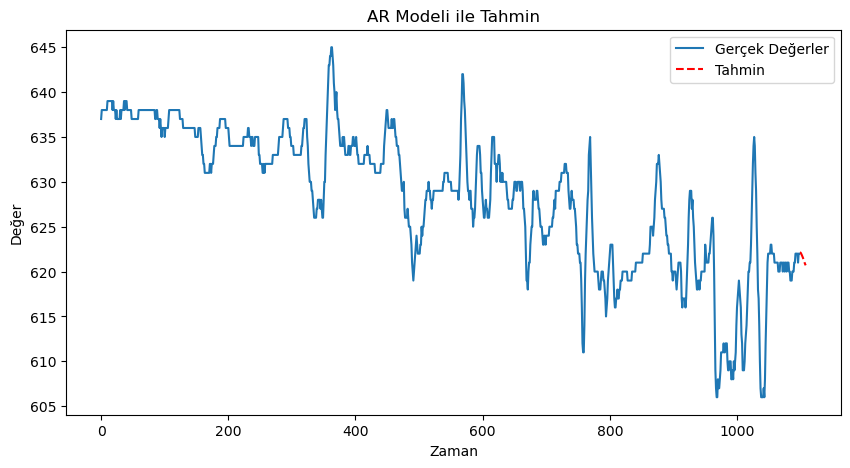

Tahmin edilen gelecek değerler:
1099    622.134493
1100    622.115892
1101    621.986173
1102    621.831704
1103    621.663724
1104    621.480203
1105    621.284159
1106    621.053260
1107    620.855755
1108    620.696795
dtype: float64


In [7]:
import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
import matplotlib.pyplot as plt

# Veri setini yükleme
file_path = "data/lip_0_x.csv"
df = pd.read_csv(file_path)

# Zaman serisini seçme
time_series = df["0_x"]

# ADF durağanlık testi
def adf_test(series):
    result = adfuller(series.dropna())
    print("ADF Test İstatistiği:", result[0])
    print("p-Değeri:", result[1])
    print("Kritik Değerler:", result[4])
    return result[1]  # p-value döndür

print("Orijinal serinin durağanlık testi:")
p_value = adf_test(time_series)

# Eğer durağan değilse fark alarak durağan hale getirme
if p_value > 0.05:
    df["0_x_diff"] = df["0_x"].diff().dropna()
    print("Fark alınmış serinin durağanlık testi:")
    p_value_diff = adf_test(df["0_x_diff"])
else:
    df["0_x_diff"] = df["0_x"]

# En iyi gecikme süresini belirleme (AIC kriterine göre)
best_lag = None
best_aic = np.inf

for lag in range(1, 21):  # 1'den 20'ye kadar farklı gecikme değerlerini test edelim
    try:
        model = AutoReg(df["0_x_diff"].dropna(), lags=lag).fit()
        if model.aic < best_aic:
            best_aic = model.aic
            best_lag = lag
    except:
        continue

print("En iyi gecikme süresi:", best_lag)

# AR modelini en iyi lag değeri ile eğitme
model = AutoReg(df["0_x_diff"].dropna(), lags=best_lag).fit()

# Tahmin yapma (gelecek 10 adımı tahmin edelim)
future_steps = 10
forecast = model.predict(start=len(df), end=len(df) + future_steps - 1)

# Tahmin edilen farkları orijinal zaman serisine ekleyerek gerçek tahminleri oluşturma
last_value = df["0_x"].iloc[-1]
forecast_values = last_value + forecast.cumsum()

# Sonuçları görselleştirme
plt.figure(figsize=(10, 5))
plt.plot(df.index, df["0_x"], label="Gerçek Değerler")
plt.plot(range(len(df), len(df) + future_steps), forecast_values, label="Tahmin", linestyle='dashed', color='red')
plt.xlabel("Zaman")
plt.ylabel("Değer")
plt.title("AR Modeli ile Tahmin")
plt.legend()
plt.show()

# Tahmin edilen değerleri yazdırma
print("Tahmin edilen gelecek değerler:")
print(forecast_values)

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, root_mean_squared_error

# Veriyi yükleme
file_path = "data/lip_0_x.csv"
df = pd.read_csv(file_path)

# Zaman serisi verisini seçme
series = df['0_x']

# AR modeli uygulama
lag = 1  # Gecikme sayısı ayarlanabilir
ar_model = AutoReg(series, lags=lag)
ar_result = ar_model.fit()
pred_ar = ar_result.predict(start=lag, end=len(series)-1)

# Performans ölçümleri
mape_ar = mean_absolute_percentage_error(series[lag:], pred_ar)
mae_ar = mean_absolute_error(series[lag:], pred_ar)
mse_ar = mean_squared_error(series[lag:], pred_ar)
rmse_ar = root_mean_squared_error(series[lag:], pred_ar)

# Sonuçları ekrana yazdırma
print("Gerçek Değerler:")
print(series[lag:].values)
print("Tahmin Edilen Değerler:")
print(pred_ar.values)
print(f'AR Modeli MAPE: {mape_ar:.4f}')
print(f'AR Modeli MAE: {mae_ar:.4f}')
print(f'AR Modeli MSE: {mse_ar:.4f}')
print(f'AR Modeli RMSE: {rmse_ar:.4f}')

Gerçek Değerler:
[638 638 638 ... 621 622 622]
Tahmin Edilen Değerler:
[636.90853768 637.89946337 637.89946337 ... 622.04465244 621.05372676
 622.04465244]
AR Modeli MAPE: 0.0010
AR Modeli MAE: 0.6391
AR Modeli MSE: 1.0686
AR Modeli RMSE: 1.0337


In [21]:
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, root_mean_squared_error

# Veriyi yükleme
file_path = "data/lip_0_x.csv"
df = pd.read_csv(file_path)

# Zaman serisi verisini seçme
series = df['0_x']
time_series = df['time']  # Zaman bilgisini al

# AR modeli uygulama
lag = 1  # Gecikme sayısı ayarlanabilir
ar_model = AutoReg(series, lags=lag)
ar_result = ar_model.fit()
pred_ar = ar_result.predict(start=lag, end=len(series)-1)

# SQLite veritabanı bağlantısı oluşturma
try:
    conn = sqlite3.connect("text_action.db")
    cursor = conn.cursor()

    # Tahmin sonuçları için tablo oluşturma
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS ar_prediction_results (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            time REAL NOT NULL,
            actual_value INTEGER NOT NULL,
            predicted_value REAL NOT NULL,
            mae REAL NOT NULL,
            mse REAL NOT NULL,
            rmse REAL NOT NULL,
            mape REAL NOT NULL
        )
    ''')

    # Gerçek ve tahmin edilen değerleri veritabanına kaydetme (Her satırda farklı hata metriği olacak şekilde)
    records = []
    for idx in range(lag, len(series)):
        actual_val = float(series.iloc[idx])
        pred_val = pred_ar.iloc[idx - lag]  
        time_val = time_series.iloc[idx] 

        # Hata metriklerini hesapla
        mae = mean_absolute_error([actual_val], [pred_val])
        mse = mean_squared_error([actual_val], [pred_val])
        rmse = root_mean_squared_error([actual_val], [pred_val])
        mape = mean_absolute_percentage_error([actual_val], [pred_val])

        # Tek satırda tüm hata metrikleriyle birlikte kaydet
        records.append((time_val, actual_val, pred_val, mae, mse, rmse, mape))
    
    # Verileri topluca ekleme
    cursor.executemany('''
        INSERT INTO ar_prediction_results (time, actual_value, predicted_value, mae, mse, rmse, mape)
        VALUES (?, ?, ?, ?, ?, ?, ?)
    ''', records)

    # Değişiklikleri kaydet
    conn.commit()
    print("AR Modeli tahmin sonuçları başarıyla veritabanına kaydedildi.")

except sqlite3.Error as e:
    print(f"Veritabanı hatası: {e}")

finally:
    # Bağlantıyı kapat
    if conn:
        conn.close()

AR Modeli tahmin sonuçları başarıyla veritabanına kaydedildi.


In [20]:
conn = sqlite3.connect("text_action.db")
cursor = conn.cursor()

cursor.execute("DROP TABLE IF EXISTS ar_prediction_results")
conn.commit()
conn.close()

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, root_mean_squared_error

# Veriyi yükleme
file_path = "data/lip_0_x.csv"
df = pd.read_csv(file_path)

# Zaman serisi verisini seçme
series = df['0_x']
time_series = df['time']  # Zaman bilgisini al

# MA modeli uygulama (ARIMA(0,0,q) = MA(q))
ma_model = ARIMA(series, order=(0, 0, 1), enforce_invertibility=False)
ma_result = ma_model.fit()
pred_ma = ma_result.predict(start=1, end=len(series)-1)

# Performans ölçümleri
mape_ma = mean_absolute_percentage_error(series[1:], pred_ma)
mae_ma = mean_absolute_error(series[1:], pred_ma)
mse_ma = mean_squared_error(series[1:], pred_ma)
rmse_ma = root_mean_squared_error(series[1:], pred_ma)

# Sonuçları ekrana yazdırma
print("Gerçek Değerler:")
print(series[1:].values)
print("Tahmin Edilen Değerler:")
print(pred_ma.values)
print(f'MA Modeli MAPE: {mape_ma:.4f}')
print(f'MA Modeli MAE: {mae_ma:.4f}')
print(f'MA Modeli MSE: {mse_ma:.4f}')
print(f'MA Modeli RMSE: {rmse_ma:.4f}')

Gerçek Değerler:
[638 638 638 ... 621 622 622]
Tahmin Edilen Değerler:
[632.69942415 631.93935761 632.93937069 ... 625.30963834 624.4060143
 626.17922498]
MA Modeli MAPE: 0.0055
MA Modeli MAE: 3.4418
MA Modeli MSE: 17.4225
MA Modeli RMSE: 4.1740


In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, root_mean_squared_error

# Veriyi yükleme
file_path = "data/lip_0_x.csv"
df = pd.read_csv(file_path)

# Zaman serisi verisini seçme
series = df['0_x']

# MA modeli uygulama (ARIMA(0,0,q) = MA(q))
ma_model = ARIMA(series, order=(0, 0, 1), enforce_invertibility=False)
ma_result = ma_model.fit()
pred_ma = ma_result.predict(start=1, end=len(series)-1)

# SQLite veritabanı bağlantısı oluşturma
try:
    conn = sqlite3.connect("text_action.db")
    cursor = conn.cursor()

    # Tahmin sonuçları için tablo oluşturma
    cursor.execute('''
        CREATE TABLE IF NOT EXISTS ma_prediction_results (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            time REAL NOT NULL,
            actual_value INTEGER NOT NULL,
            predicted_value REAL NOT NULL,
            mae REAL NOT NULL,
            mse REAL NOT NULL,
            rmse REAL NOT NULL,
            mape REAL NOT NULL
        )
    ''')

    # Gerçek ve tahmin edilen değerleri veritabanına kaydetme (Her satırda farklı hata metriği olacak şekilde)
    records = []
    for idx in range(lag, len(series)):
        actual_val = float(series.iloc[idx])
        pred_val = pred_ar.iloc[idx - lag]  
        time_val = time_series.iloc[idx] 

        # Hata metriklerini hesapla
        mae = mean_absolute_error([actual_val], [pred_val])
        mse = mean_squared_error([actual_val], [pred_val])
        rmse = root_mean_squared_error([actual_val], [pred_val])
        mape = mean_absolute_percentage_error([actual_val], [pred_val])

        # Tek satırda tüm hata metrikleriyle birlikte kaydet
        records.append((time_val, actual_val, pred_val, mae, mse, rmse, mape))
    
    # Verileri topluca ekleme
    cursor.executemany('''
        INSERT INTO ma_prediction_results (time, actual_value, predicted_value, mae, mse, rmse, mape)
        VALUES (?, ?, ?, ?, ?, ?, ?)
    ''', records)

    # Değişiklikleri kaydet
    conn.commit()
    print("MA Modeli tahmin sonuçları başarıyla veritabanına kaydedildi.")

except sqlite3.Error as e:
    print(f"Veritabanı hatası: {e}")

finally:
    # Bağlantıyı kapat
    if conn:
        conn.close()

MA Modeli tahmin sonuçları başarıyla veritabanına kaydedildi.


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, root_mean_squared_error

# Veriyi yükleme
file_path = "data/lip_0_x.csv"
df = pd.read_csv(file_path)

# Zaman serisi verisini seçme
series = df['0_x']

# ARMA modeli uygulama (d = 0 olduğundan ARIMA(p,0,q) = ARMA(p,q))
arma_model = ARIMA(series, order=(1, 0, 1)) # ARMA(p, q) modeli
arma_result = arma_model.fit()
pred_arma = arma_result.predict(start=1, end=len(series)-1, typ='levels')

# Performans ölçümleri
mape_arma = mean_absolute_percentage_error(series[1:], pred_arma)
mae_arma = mean_absolute_error(series[1:], pred_arma)
mse_arma = mean_squared_error(series[1:], pred_arma)
rmse_arma = root_mean_squared_error(series[1:], pred_arma)

# Sonuçları ekrana yazdırma
print("Gerçek Değerler:")
print(series[1:].values)
print("Tahmin Edilen Değerler:")
print(pred_arma.values)
print(f'ARMA Modeli MAPE: {mape_arma:.4f}')
print(f'ARMA Modeli MAE: {mae_arma:.4f}')
print(f'ARMA Modeli MSE: {mse_arma:.4f}')
print(f'ARMA Modeli RMSE: {rmse_arma:.4f}')

Gerçek Değerler:
[638 638 638 ... 621 622 622]
Tahmin Edilen Değerler:
[636.9236697  638.37269273 638.00353777 ... 622.11918366 620.70573472
 622.39751085]
ARMA Modeli MAPE: 0.0010
ARMA Modeli MAE: 0.6230
ARMA Modeli MSE: 0.7807
ARMA Modeli RMSE: 0.8836


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, root_mean_squared_error

# Veriyi yükleme
file_path = "data/lip_0_x.csv"
df = pd.read_csv(file_path)

# Zaman serisi verisini seçme
series = df['0_x']

# ARIMA modeli uygulama
arima_model = ARIMA(series, order=(1, 1, 1) )
arima_result = arima_model.fit()
pred_arima = arima_result.predict(start=1, end=len(series)-1, typ='levels')

# Performans ölçümleri
mape_arima = mean_absolute_percentage_error(series[1:], pred_arima)
mae_arima = mean_absolute_error(series[1:], pred_arima)
mse_arima = mean_squared_error(series[1:], pred_arima)
rmse_arima = root_mean_squared_error(series[1:], pred_arima)

# Sonuçları ekrana yazdırma
print("Gerçek Değerler:")
print(series[1:].values)
print("Tahmin Edilen Değerler:")
print(pred_arima.values)
print(f'ARIMA Modeli MAPE: {mape_arima:.4f}')
print(f'ARIMA Modeli MAE: {mae_arima:.4f}')
print(f'ARIMA Modeli MSE: {mse_arima:.4f}')
print(f'ARIMA Modeli RMSE: {rmse_arima:.4f}')

Gerçek Değerler:
[638 638 638 ... 621 622 622]
Tahmin Edilen Değerler:
[637.00033683 638.49282495 638.13549854 ... 622.01002675 620.5823951
 622.30327038]
ARIMA Modeli MAPE: 0.0010
ARIMA Modeli MAE: 0.6091
ARIMA Modeli MSE: 0.7966
ARIMA Modeli RMSE: 0.8925


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, root_mean_squared_error

# Veriyi yükleme
file_path = "data/lip_0_x.csv"
df = pd.read_csv(file_path)

# Zaman serisi verisini seçme
series = df['0_x']

# SARIMA modeli uygulama (p, d, q) x (P, D, Q, s)
# ARIMA parametreleri (p, d, q)
# Mevsimsel parametreler (P, D, Q, s)
sarima_model = SARIMAX(series, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0) )
sarima_result = sarima_model.fit()
pred_sarima = sarima_result.predict(start=1, end=len(series)-1, typ='levels')

# Performans ölçümleri
mape_sarima = mean_absolute_percentage_error(series[1:], pred_sarima)
mae_sarima = mean_absolute_error(series[1:], pred_sarima)
mse_sarima = mean_squared_error(series[1:], pred_sarima)
rmse_sarima = root_mean_squared_error(series[1:], pred_sarima)

# Sonuçları ekrana yazdırma
print("Gerçek Değerler:")
print(series[1:].values)
print("Tahmin Edilen Değerler:")
print(pred_sarima.values)
print(f'SARIMA Modeli MAPE: {mape_sarima:.4f}')
print(f'SARIMA Modeli MAE: {mae_sarima:.4f}')
print(f'SARIMA Modeli MSE: {mse_sarima:.4f}')
print(f'SARIMA Modeli RMSE: {rmse_sarima:.4f}')

Gerçek Değerler:
[638 638 638 ... 621 622 622]
Tahmin Edilen Değerler:
[637.00033683 638.49282495 638.13549854 ... 622.01002675 620.5823951
 622.30327038]
SARIMA Modeli MAPE: 0.0010
SARIMA Modeli MAE: 0.6091
SARIMA Modeli MSE: 0.7966
SARIMA Modeli RMSE: 0.8925


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, root_mean_squared_error

# Veriyi yükleme
file_path = "data/lip_0_x.csv"
df = pd.read_csv(file_path)

# Zaman serisi verisini seçme
series = df['0_x']

# Exojen değişkenler eklenebilir (Varsa, burada belirleyin)
exog = None  # Eğer dışsal değişkenler varsa, buraya bir DataFrame ekleyin

# SARIMAX modeli uygulama (p, d, q) x (P, D, Q, s)
# ARIMA parametreleri (p, d, q)
# Mevsimsel parametreler (P, D, Q, s)
sarimax_model = SARIMAX(series, order=(1, 1, 1), seasonal_order=(0, 0, 0, 0), exog=exog)
sarimax_result = sarimax_model.fit()
pred_sarimax = sarimax_result.predict(start=1, end=len(series)-1, exog=exog, typ='levels')

# Performans ölçümleri
mape_sarimax = mean_absolute_percentage_error(series[1:], pred_sarimax)
mae_sarimax = mean_absolute_error(series[1:], pred_sarimax)
mse_sarimax = mean_squared_error(series[1:], pred_sarimax)
rmse_sarimax = root_mean_squared_error(series[1:], pred_sarimax)

# Sonuçları ekrana yazdırma
print("Gerçek Değerler:")
print(series[1:].values)
print("Tahmin Edilen Değerler:")
print(pred_sarimax.values)
print(f'SARIMAX Modeli MAPE: {mape_sarimax:.4f}')
print(f'SARIMAX Modeli MAE: {mae_sarimax:.4f}')
print(f'SARIMAX Modeli MSE: {mse_sarimax:.4f}')
print(f'SARIMAX Modeli RMSE: {rmse_sarimax:.4f}')

Gerçek Değerler:
[638 638 638 ... 621 622 622]
Tahmin Edilen Değerler:
[637.00033683 638.49282495 638.13549854 ... 622.01002675 620.5823951
 622.30327038]
SARIMAX Modeli MAPE: 0.0010
SARIMAX Modeli MAE: 0.6091
SARIMAX Modeli MSE: 0.7966
SARIMAX Modeli RMSE: 0.8925
